In [1]:
import torch
import matplotlib.pyplot as plt
from models.mlp import run

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [4]:
path = "./normalized_images"

# Hyperparameters
# Additionally, set test flag to True to run on test set after training, which will print the test loss and accuracy.
num_epochs = 20
lr = 1e-4

model, train_losses, eval_losses, eval_preds, eval_labels, test_preds, test_labels = run(path, device, num_epochs=num_epochs, lr=lr, test=True)

-- MLP | Epochs: 20 | LR: 0.0001
Epoch 1/20 - Train Loss: 0.4010, Eval Loss: 0.2513
Epoch 2/20 - Train Loss: 0.2962, Eval Loss: 0.2172
Epoch 3/20 - Train Loss: 0.2555, Eval Loss: 0.2243
Epoch 4/20 - Train Loss: 0.2487, Eval Loss: 0.2106
Epoch 5/20 - Train Loss: 0.2396, Eval Loss: 0.2146
Epoch 6/20 - Train Loss: 0.2446, Eval Loss: 0.2041
Epoch 7/20 - Train Loss: 0.2305, Eval Loss: 0.2053
Epoch 8/20 - Train Loss: 0.2288, Eval Loss: 0.1982
Epoch 9/20 - Train Loss: 0.2255, Eval Loss: 0.2080
Epoch 10/20 - Train Loss: 0.2322, Eval Loss: 0.2066
Epoch 11/20 - Train Loss: 0.2255, Eval Loss: 0.2119
Epoch 12/20 - Train Loss: 0.2228, Eval Loss: 0.2013
Epoch 13/20 - Train Loss: 0.2115, Eval Loss: 0.2057
Epoch 14/20 - Train Loss: 0.2117, Eval Loss: 0.2012
Epoch 15/20 - Train Loss: 0.2088, Eval Loss: 0.2064
Epoch 16/20 - Train Loss: 0.2069, Eval Loss: 0.2067
Epoch 17/20 - Train Loss: 0.2002, Eval Loss: 0.1998
Epoch 18/20 - Train Loss: 0.1985, Eval Loss: 0.1986
Epoch 19/20 - Train Loss: 0.1970, Eval L

# Training / Evaluation of MLP Classifier

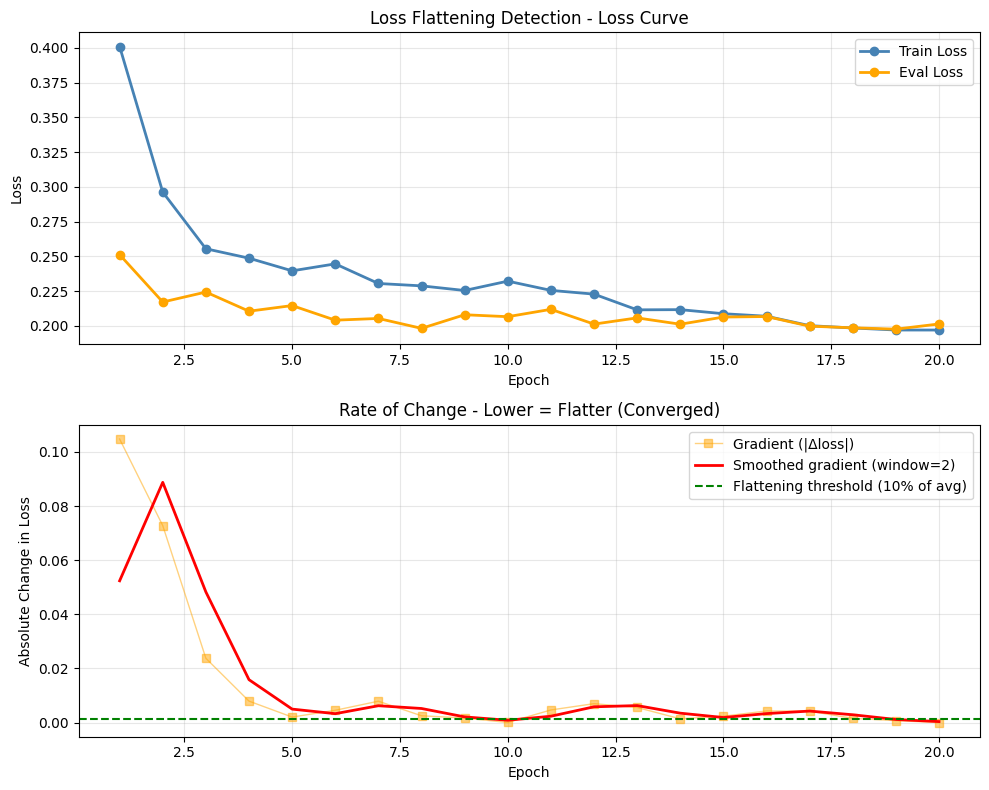


✓ Loss appears to flatten starting around epoch 10


In [5]:
from graphs import plot_loss_flattening
plot_loss_flattening(train_losses, eval_losses, window_size=2)

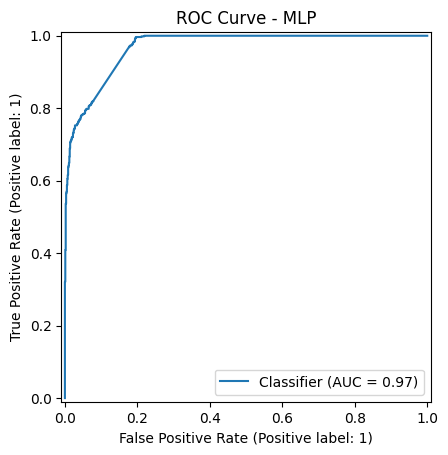

In [6]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(eval_labels, eval_preds)
plt.title("ROC Curve - MLP")
plt.show()

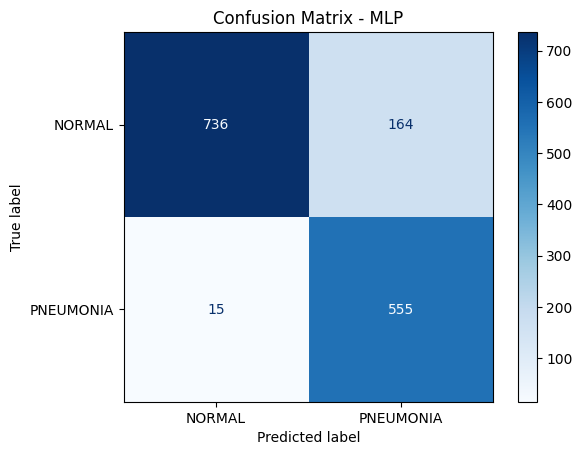

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(eval_labels, eval_preds.round(), display_labels=["NORMAL", "PNEUMONIA"], cmap="Blues")
plt.title("Confusion Matrix - MLP")
plt.show()

# Testing Results of MLP Classifier

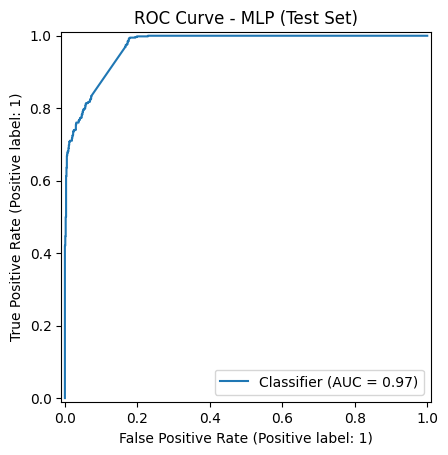

In [8]:
RocCurveDisplay.from_predictions(test_labels, test_preds)
plt.title("ROC Curve - MLP (Test Set)")
plt.show()

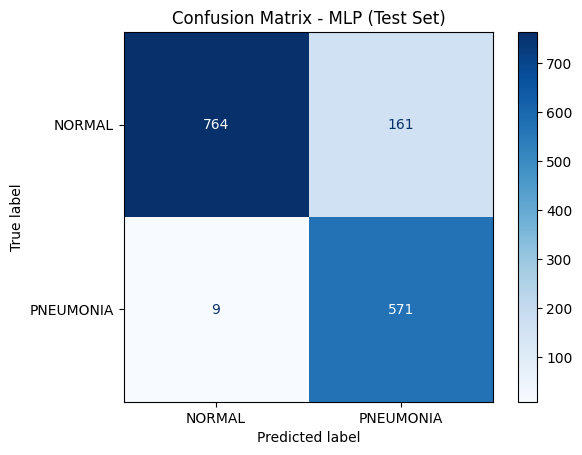

In [9]:
ConfusionMatrixDisplay.from_predictions(test_labels, test_preds.round(), display_labels=["NORMAL", "PNEUMONIA"], cmap="Blues")
plt.title("Confusion Matrix - MLP (Test Set)")
plt.show()